# CSCI 3202, Spring 2026
### Project Intermediate Report
### Copy and pasted HW 6 to build off of existing Mancala code

<br> 

### Your name: Evan Mohan & Jake Huebner

<br> 

---

# Mancala Game Implementation (IGNORE, from HW6)

In this assignment, you are tasked with implementing various functions for a Mancala game. The game is played on a board with specific rules, and you will need to implement the core game logic by completing the `play`, `valid_move`, and `winning_eval` functions. You are provided with the `init` and `display_board` functions. The assignment is divided into two parts:

## Mancala rules for this homework assignment


**(there are many different rules sets for Mancala.  Please read this before writing the code)**

* Players sit on opposite sides of the long edge of the board
* There are 6 small pits in the middle of the board and 2 large ones at each end.  The small ones in the middle and the large pit on your right are yours.  The small ones on the other side and the large pit to your opponent's right are theirs
* The large pits at the end of the board are called Mancalas
* Set up the board with 4 stones per small pit (none in the mancalas)
* On every turn, select a pit on your side of the board that contains one or more stones,  then distribute its stones, one stone per pit, in an counter-clockwise direction until you have no stones remaining
* If you encounter your opponent's mandala, skip it
* If you encounter your mancala, drop a stone into it
* If the last stone lands in an empty pit on your side of the board, capture this stone and any stones in your opponent's pit on the other side of the board, collect all of these stones, including the one that just landed, and place them into your mancala.
* If either player's pits are entirely empty, the game concludes. 
* The player who still has stones on his side of the board when the game concludes places all of these pieces into their mancala.
The player with the most stones in their mancala is declared the winner. If both players have an equal number of stones in their mancala, the game results in a tie.


## Part 1: Small Board (3 Pits of 2 Stones each) (IGNORE, from HW6)





For the first part of the assignment, students will work on a small Mancala board. The board consists of 3 pits, each initially containing 2 stones. The students need to implement the following:

1. **play**: Implement the `play` function to allow players to take turns and make moves. The function should correctly distribute stones according to the specified game rules. The game should also switch between players after each play. **(20 points)**

2. **valid_move**: Implement the `valid_move` function to ensure that a player's chosen move is valid. It should check if the selected pit is not empty and falls within the allowed pit range. **(20 points)**

3. **winning_eval**: Implement the `winning_eval` function to determine when the game is over and which player wins. The game ends when any player's pits are all empty. The winner is the player with the most stones in their mancala. If both mancalas have the same number of stones, it's a tie. **(20 points)**

Students should test their code by playing a sequence of moves shown below.

P1 picks pit 1, P2 picks pit 2, P1 picks pit 3...and so on.  The pits are 1-indexed when displaying and picking to make a move.  Make sure that your code gives an invalid move error when the pit chosen is empty or the pit choice is out of range.


## Part 2: Play Against a Random Player (6 Pits of 4 Stones each) (IGNORE, from HW6) run the Mancala class box

In the second part of the assignment, students will extend their implementation to a larger board. The board consists of 6 pits with 4 stones in each pit. In addition to the `play`, `valid_move`, and `winning_eval` functions, students need to create a random move generator for a random player. This random player selects a random valid pit with stones to make a move. The following steps are involved in creating the random move generator:

1. **Random Move Generator**: Define the `random_move_generator` that selects a random pit from the available non-empty pits for the random player. The random player should choose a move based on these criteria. \
Set the 'seed' value to ensure that the generated values remain consistent and reproducible when grading.

You may refer to these links: [How to generate random integers in Python](https://machinelearningmastery.com/how-to-generate-random-numbers-in-python/#:~:text=Random%20integer%20values%20can%20be,for%20the%20generated%20integer%20values.), [How to use seed in Python random](https://www.w3schools.com/python/ref_random_seed.asp)


The objective is to play up to **10** moves in total (5 moves by student, 5 moves by random player), allowing the students to verify whether their code correctly implements the Mancala game logic. **(20 points for correct implementation of Random Move Generator)**

The output submitted should reflect the state of the board and the moves played. **(10 points for playing game, 10 points for printing out results)**

**Please make sure to call the `display_board` function after each move for both the parts and run all the cells before submitting**

In [1]:
import random
random.seed(109)

In [2]:
class Mancala:
    def __init__(self, pits_per_player=6, stones_per_pit = 4):
        """
        The constructor for the Mancala class defines several instance variables:

        pits_per_player: This variable stores the number of pits each player has.
        stones_per_pit: It represents the number of stones each pit contains at the start of any game.
        board: This data structure is responsible for managing the Mancala board.
        current_player: This variable takes the value 1 or 2, as it's a two-player game, indicating which player's turn it is.
        moves: This is a list used to store the moves made by each player. It's structured in the format (current_player, chosen_pit).
        p1_pits_index: A list containing two elements representing the start and end indices of player 1's pits in the board data structure.
        p2_pits_index: Similar to p1_pits_index, it contains the start and end indices for player 2's pits on the board.
        p1_mancala_index and p2_mancala_index: These variables hold the indices of the Mancala pits on the board for players 1 and 2, respectively.
        """
        self.pits_per_player = pits_per_player
        self.board = [stones_per_pit] * ((pits_per_player+1) * 2)  # Initialize each pit with stones_per_pit number of stones 
        self.players = 2
        self.current_player = 1
        self.moves = []
        self.p1_pits_index = [0, self.pits_per_player-1]
        self.p1_mancala_index = self.pits_per_player
        self.p2_pits_index = [self.pits_per_player+1, len(self.board)-1-1]
        self.p2_mancala_index = len(self.board)-1
        
        # Zeroing the Mancala for both players
        self.board[self.p1_mancala_index] = 0
        self.board[self.p2_mancala_index] = 0

    def display_board(self):
        """
        Displays the board in a user-friendly format
        """
        player_1_pits = self.board[self.p1_pits_index[0]: self.p1_pits_index[1]+1]
        player_1_mancala = self.board[self.p1_mancala_index]
        player_2_pits = self.board[self.p2_pits_index[0]: self.p2_pits_index[1]+1]
        player_2_mancala = self.board[self.p2_mancala_index]

        print('P1               P2')
        print('     ____{}____     '.format(player_2_mancala))
        for i in range(self.pits_per_player):
            if i == self.pits_per_player - 1:
                print('{} -> |_{}_|_{}_| <- {}'.format(i+1, player_1_pits[i], 
                        player_2_pits[-(i+1)], self.pits_per_player - i))
            else:    
                print('{} -> | {} | {} | <- {}'.format(i+1, player_1_pits[i], 
                        player_2_pits[-(i+1)], self.pits_per_player - i))
            
        print('         {}         '.format(player_1_mancala))
        turn = 'P1' if self.current_player == 1 else 'P2'
        print('Turn: ' + turn)
        
    def valid_move(self, pit):
        """
        Function to check if the pit chosen by the current_player is a valid move.
        """
        if pit < 1 or pit > self.pits_per_player:
            return False

        if self.current_player == 1:
            board_index = self.p1_pits_index[0] + (pit - 1)
        else:
            board_index = self.p2_pits_index[0] + (pit - 1)

        return self.board[board_index] > 0
        
    def random_move_generator(self):
        """
        Function to generate random valid moves with non-empty pits for the random player
        """
        valid_pits = [pit for pit in range(1, self.pits_per_player + 1) if self.valid_move(pit)]
        if not valid_pits:
            return None
        return random.choice(valid_pits)
    
    def play(self, pit):
        """
        This function simulates a single move made by a specific player using their selected pit. It primarily performs three tasks:
        1. It checks if the chosen pit is a valid move for the current player. If not, it prints "INVALID MOVE" and takes no action.
        2. It verifies if the game board has already reached a winning state. If so, it prints "GAME OVER" and takes no further action.
        3. After passing the above two checks, it proceeds to distribute the stones according to the specified Mancala rules.

        Finally, the function then switches the current player, allowing the other player to take their turn.
        """
        
        if self.winning_eval() is not None:
            print("GAME OVER")
            return self.board

        if not self.valid_move(pit):
            print("INVALID MOVE")
            return self.board

        # convert 1-indexed pit to actual board index
        if self.current_player == 1:
            idx = self.p1_pits_index[0] + (pit - 1)
            own_mancala = self.p1_mancala_index
            opp_mancala = self.p2_mancala_index
            own_start, own_end = self.p1_pits_index
        else:
            idx = self.p2_pits_index[0] + (pit - 1)
            own_mancala = self.p2_mancala_index
            opp_mancala = self.p1_mancala_index
            own_start, own_end = self.p2_pits_index

        stones = self.board[idx]
        self.board[idx] = 0
        current_idx = idx

        # sow stones counter-clockwise through the linear board representation
        while stones > 0:
            current_idx = (current_idx + 1) % len(self.board)

            # skip opponent's mancala
            if current_idx == opp_mancala:
                continue

            self.board[current_idx] += 1
            stones -= 1

        # capture rule: last stone lands in an empty pit on your side
        if own_start <= current_idx <= own_end and self.board[current_idx] == 1:
            opposite_idx = 2 * self.pits_per_player - current_idx
            if self.board[opposite_idx] > 0:
                captured = self.board[current_idx] + self.board[opposite_idx]
                self.board[own_mancala] += captured
                self.board[current_idx] = 0
                self.board[opposite_idx] = 0

        # record move
        self.moves.append((self.current_player, pit))

        # if game ends after this move, sweep remaining stones
        winner = self.winning_eval()
        if winner is not None:
            p1_remaining = sum(self.board[self.p1_pits_index[0]:self.p1_pits_index[1]+1])
            p2_remaining = sum(self.board[self.p2_pits_index[0]:self.p2_pits_index[1]+1])

            self.board[self.p1_mancala_index] += p1_remaining
            self.board[self.p2_mancala_index] += p2_remaining

            for i in range(self.p1_pits_index[0], self.p1_pits_index[1]+1):
                self.board[i] = 0
            for i in range(self.p2_pits_index[0], self.p2_pits_index[1]+1):
                self.board[i] = 0

            return self.board

        # switch player after every play for this homework
        self.current_player = 2 if self.current_player == 1 else 1
        return self.board
    
    def winning_eval(self):
        """
        Function to verify if the game board has reached the winning state.
        Hint: If either of the players' pits are all empty, then it is considered a winning state.
        """
        """
        Returns:
        1 if player 1 wins
        2 if player 2 wins
        0 if tie
        None if game is not over
        """
        p1_empty = all(self.board[i] == 0 for i in range(self.p1_pits_index[0], self.p1_pits_index[1]+1))
        p2_empty = all(self.board[i] == 0 for i in range(self.p2_pits_index[0], self.p2_pits_index[1]+1))

        if not (p1_empty or p2_empty):
            return None

        p1_score = self.board[self.p1_mancala_index] + sum(
            self.board[self.p1_pits_index[0]:self.p1_pits_index[1]+1]
        )
        p2_score = self.board[self.p2_mancala_index] + sum(
            self.board[self.p2_pits_index[0]:self.p2_pits_index[1]+1]
        )

        if p1_score > p2_score:
            return 1
        elif p2_score > p1_score:
            return 2
        else:
            return 0


### HW6 Stuff, don't have to run for the project

In [3]:
# Mancala part 1: 3 pits, 2 stones each
game = Mancala(3, 2)
game.display_board()

game.play(1)   # P1 picks pit 1
game.display_board()

game.play(2)   # P2 picks pit 2
game.display_board()

game.play(3)   # P1 picks pit 3
game.display_board()

game.play(2)   # P2 picks pit 2
game.display_board()

game.play(1)   # P1 picks pit 1
game.display_board()

print("\nList of valid moves:")
for move in game.moves:
    player, pit = move
    print(f"Player {player} selected pit {pit}")

result = game.winning_eval()
if result == 1:
    print("Player 1 wins")
elif result == 2:
    print("Player 2 wins")
elif result == 0:
    print("Tie game")
else:
    print("Game not over yet")

P1               P2
     ____0____     
1 -> | 2 | 2 | <- 3
2 -> | 2 | 2 | <- 2
3 -> |_2_|_2_| <- 1
         0         
Turn: P1
P1               P2
     ____0____     
1 -> | 0 | 2 | <- 3
2 -> | 3 | 2 | <- 2
3 -> |_3_|_2_| <- 1
         0         
Turn: P2
P1               P2
     ____1____     
1 -> | 0 | 3 | <- 3
2 -> | 3 | 0 | <- 2
3 -> |_3_|_2_| <- 1
         0         
Turn: P1
P1               P2
     ____1____     
1 -> | 0 | 3 | <- 3
2 -> | 3 | 1 | <- 2
3 -> |_0_|_3_| <- 1
         1         
Turn: P2
P1               P2
     ____1____     
1 -> | 0 | 4 | <- 3
2 -> | 3 | 0 | <- 2
3 -> |_0_|_3_| <- 1
         1         
Turn: P1
INVALID MOVE
P1               P2
     ____1____     
1 -> | 0 | 4 | <- 3
2 -> | 3 | 0 | <- 2
3 -> |_0_|_3_| <- 1
         1         
Turn: P1

List of valid moves:
Player 1 selected pit 1
Player 2 selected pit 2
Player 1 selected pit 3
Player 2 selected pit 2
Game not over yet


#### Expected output for part 1

In [4]:
# Mancala part 2

In [5]:
# Mancala part 2: 6 pits, 4 stones each
game2 = Mancala(6, 4)
game2.display_board()

student_moves = [1, 3, 2, 6, 4]

student_turn = True
student_index = 0
total_moves = 0

while total_moves < 10 and game2.winning_eval() is None:
    if student_turn:
        pit = student_moves[student_index]
        student_index += 1
        print(f"\nPlayer 1 chooses pit {pit}")
        game2.play(pit)
    else:
        pit = game2.random_move_generator()
        print(f"\nPlayer 2 chooses pit {pit}")
        game2.play(pit)

    game2.display_board()
    total_moves += 1
    student_turn = not student_turn

print("\nMoves played:")
for move in game2.moves:
    print(move)

result = game2.winning_eval()
if result == 1:
    print("Player 1 wins")
elif result == 2:
    print("Player 2 wins")
elif result == 0:
    print("Tie game")
else:
    print("Game not over after 10 moves")

P1               P2
     ____0____     
1 -> | 4 | 4 | <- 6
2 -> | 4 | 4 | <- 5
3 -> | 4 | 4 | <- 4
4 -> | 4 | 4 | <- 3
5 -> | 4 | 4 | <- 2
6 -> |_4_|_4_| <- 1
         0         
Turn: P1

Player 1 chooses pit 1
P1               P2
     ____0____     
1 -> | 0 | 4 | <- 6
2 -> | 5 | 4 | <- 5
3 -> | 5 | 4 | <- 4
4 -> | 5 | 4 | <- 3
5 -> | 5 | 4 | <- 2
6 -> |_4_|_4_| <- 1
         0         
Turn: P2

Player 2 chooses pit 3
P1               P2
     ____1____     
1 -> | 0 | 5 | <- 6
2 -> | 5 | 5 | <- 5
3 -> | 5 | 5 | <- 4
4 -> | 5 | 0 | <- 3
5 -> | 5 | 4 | <- 2
6 -> |_4_|_4_| <- 1
         0         
Turn: P1

Player 1 chooses pit 3
P1               P2
     ____1____     
1 -> | 0 | 5 | <- 6
2 -> | 5 | 5 | <- 5
3 -> | 0 | 5 | <- 4
4 -> | 6 | 0 | <- 3
5 -> | 6 | 4 | <- 2
6 -> |_5_|_5_| <- 1
         1         
Turn: P2

Player 2 chooses pit 2
P1               P2
     ____1____     
1 -> | 0 | 6 | <- 6
2 -> | 5 | 6 | <- 5
3 -> | 0 | 6 | <- 4
4 -> | 6 | 1 | <- 3
5 -> | 6 | 0 | <- 2
6 -> |_5

## Mancala Game Project Intermediate Report Implementation

In [6]:
# Function for 100 game simulations
# Returns Player 1 & 2 wins as well as ties

def simulate_games(num_games=100):
    results = {
        "p1_wins": 0,
        "p2_wins": 0,
        "ties": 0,
        "total_turns": 0
    }

    for _ in range(num_games):
        game = Mancala(6, 4)
        turn_count = 0

        while game.winning_eval() is None:
            pit = game.random_move_generator()
            game.play(pit)
            turn_count += 1

        winner = game.winning_eval()

        if winner == 1:
            results["p1_wins"] += 1
        elif winner == 2:
            results["p2_wins"] += 1
        else:
            results["ties"] += 1

        results["total_turns"] += turn_count

    return results

In [7]:
results = simulate_games(100)

total = 100
# Prints Player 1 win percent
print("Player 1 wins:", results["p1_wins"], results["p1_wins"]/total)

# Prints Player 2 win percent
print("Player 2 wins:", results["p2_wins"], results["p2_wins"]/total)

# Prints percent of ties
print("Ties:", results["ties"], results["ties"]/total)

# Prints average amount of turns per game
avg_turns = results["total_turns"] / total
print("Average turns per game:", avg_turns)

Player 1 wins: 45 0.45
Player 2 wins: 50 0.5
Ties: 5 0.05
Average turns per game: 45.07


### Based on the above generation which for me is 

Player 1 wins: 51 0.51
Player 2 wins: 40 0.4
Ties: 9 0.09
Average turns per game: 43.58

### Analysis

The simulation indicate a slight first-move advantage for Player 1. Player 1 won 51% of the games, compared to 40% for Player 2. This aligns with our expectations, as the first player has the opportunity to control the board state from the beginning of the game.

The presence of ties (9%) shows that some games result in balanced outcomes, but overall Player 1 maintains the advantage. The average number of turns per game (43.58) suggests that the game progresses at a reasonable pace and that the implementation correctly handles game termination conditions.

### Conclusion

Based on the results, there is a small but noticeable first move advantage in Mancala. This advantage is due to Player 1 having the first opportunity to distribute stones and influence the game state. This allowed Player 1 to have a higher win rate than Player 2, but still results in 9 ties out of our 100 games. The results are consistent with expected behavior for random vs. random gameplay.

## Minimax code

In [8]:
import math
import copy

def clone_game(game):
    new_game = Mancala(game.pits_per_player, 0)
    new_game.board = game.board.copy()
    new_game.current_player = game.current_player
    new_game.moves = game.moves.copy()
    return new_game

def get_valid_moves(game):
    return [pit for pit in range(1, game.pits_per_player + 1) if game.valid_move(pit)]

def utility(game, ai_player):
    """
    Project utility:
    stones in AI mancala - stones in opponent mancala
    """
    if ai_player == 1:
        return game.board[game.p1_mancala_index] - game.board[game.p2_mancala_index]
    else:
        return game.board[game.p2_mancala_index] - game.board[game.p1_mancala_index]

def minimax_value(game, depth, ai_player):
    """
    Returns the minimax value of the state from the perspective of ai_player.
    """
    winner = game.winning_eval()
    if depth == 0 or winner is not None:
        return utility(game, ai_player)

    legal_moves = get_valid_moves(game)
    if not legal_moves:
        return utility(game, ai_player)

    maximizing = (game.current_player == ai_player)

    if maximizing:
        value = -math.inf
        for move in legal_moves:
            next_state = clone_game(game)
            next_state.play(move)
            value = max(value, minimax_value(next_state, depth - 1, ai_player))
        return value
    else:
        value = math.inf
        for move in legal_moves:
            next_state = clone_game(game)
            next_state.play(move)
            value = min(value, minimax_value(next_state, depth - 1, ai_player))
        return value

def minimax_best_move(game, depth):
    """
    Chooses the best move for the CURRENT player using minimax.
    """
    ai_player = game.current_player
    legal_moves = get_valid_moves(game)

    if not legal_moves:
        return None

    best_move = None
    best_value = -math.inf

    for move in legal_moves:
        next_state = clone_game(game)
        next_state.play(move)
        move_value = minimax_value(next_state, depth - 1, ai_player)

        if move_value > best_value:
            best_value = move_value
            best_move = move

    return best_move

In [9]:
def simulate_ai_vs_random(num_games=100, depth=2, ai_player=1):
    results = {
        "ai_wins": 0,
        "random_wins": 0,
        "ties": 0,
        "total_turns": 0
    }

    for _ in range(num_games):
        game = Mancala(6, 4)
        turn_count = 0

        while game.winning_eval() is None:
            if game.current_player == ai_player:
                pit = minimax_best_move(game, depth)
            else:
                pit = game.random_move_generator()

            if pit is None:
                break

            game.play(pit)
            turn_count += 1

        winner = game.winning_eval()

        if winner == ai_player:
            results["ai_wins"] += 1
        elif winner == 0:
            results["ties"] += 1
        else:
            results["random_wins"] += 1

        results["total_turns"] += turn_count

    return results

In [10]:
results_depth_2 = simulate_ai_vs_random(num_games=100, depth=2, ai_player=1)
results_depth_5 = simulate_ai_vs_random(num_games=100, depth=5, ai_player=1)

for depth, results in [(2, results_depth_2), (5, results_depth_5)]:
    total = 100
    print(f"\nMinimax depth = {depth}")
    print("AI wins:", results["ai_wins"], results["ai_wins"] / total)
    print("Random wins:", results["random_wins"], results["random_wins"] / total)
    print("Ties:", results["ties"], results["ties"] / total)
    print("Average turns per game:", results["total_turns"] / total)


Minimax depth = 2
AI wins: 92 0.92
Random wins: 8 0.08
Ties: 0 0.0
Average turns per game: 36.41

Minimax depth = 5
AI wins: 96 0.96
Random wins: 3 0.03
Ties: 1 0.01
Average turns per game: 31.02


## Alpha-Beta code

In [11]:
import math
import time

def alpha_beta_value(game, depth, ai_player, alpha, beta):
    """
    Returns the alpha-beta value of the state from the perspective of ai_player.
    """
    winner = game.winning_eval()
    if depth == 0 or winner is not None:
        return utility(game, ai_player)

    legal_moves = get_valid_moves(game)
    if not legal_moves:
        return utility(game, ai_player)

    maximizing = (game.current_player == ai_player)

    if maximizing:
        value = -math.inf
        for move in legal_moves:
            next_state = clone_game(game)
            next_state.play(move)
            value = max(value, alpha_beta_value(next_state, depth - 1, ai_player, alpha, beta))
            alpha = max(alpha, value)
            if beta <= alpha:
                break
        return value
    else:
        value = math.inf
        for move in legal_moves:
            next_state = clone_game(game)
            next_state.play(move)
            value = min(value, alpha_beta_value(next_state, depth - 1, ai_player, alpha, beta))
            beta = min(beta, value)
            if beta <= alpha:
                break
        return value

def alpha_beta_best_move(game, depth):
    """
    Chooses the best move for the CURRENT player using alpha-beta pruning.
    """
    ai_player = game.current_player
    legal_moves = get_valid_moves(game)

    if not legal_moves:
        return None

    best_move = None
    best_value = -math.inf
    alpha = -math.inf
    beta = math.inf

    for move in legal_moves:
        next_state = clone_game(game)
        next_state.play(move)
        move_value = alpha_beta_value(next_state, depth - 1, ai_player, alpha, beta)

        if move_value > best_value:
            best_value = move_value
            best_move = move

        alpha = max(alpha, best_value)

    return best_move

In [12]:
def simulate_alpha_beta_vs_random(num_games=100, depth=5, ai_player=1):
    results = {
        "ai_wins": 0,
        "random_wins": 0,
        "ties": 0,
        "total_turns": 0,
        "total_time": 0.0
    }

    for _ in range(num_games):
        game = Mancala(6, 4)
        turn_count = 0

        start_time = time.time()

        while game.winning_eval() is None:
            if game.current_player == ai_player:
                pit = alpha_beta_best_move(game, depth)
            else:
                pit = game.random_move_generator()

            if pit is None:
                break

            game.play(pit)
            turn_count += 1

        end_time = time.time()

        winner = game.winning_eval()

        if winner == ai_player:
            results["ai_wins"] += 1
        elif winner == 0:
            results["ties"] += 1
        else:
            results["random_wins"] += 1

        results["total_turns"] += turn_count
        results["total_time"] += (end_time - start_time)

    return results

In [13]:
results_ab_5 = simulate_alpha_beta_vs_random(num_games=100, depth=5, ai_player=1)
results_ab_10 = simulate_alpha_beta_vs_random(num_games=100, depth=10, ai_player=1)

for depth, results in [(5, results_ab_5), (10, results_ab_10)]:
    total = 100
    print(f"\nAlpha-Beta depth = {depth}")
    print("AI wins:", results["ai_wins"], results["ai_wins"] / total)
    print("Random wins:", results["random_wins"], results["random_wins"] / total)
    print("Ties:", results["ties"], results["ties"] / total)
    print("Average turns per game:", results["total_turns"] / total)
    print("Average time per game:", results["total_time"] / total, "seconds")


Alpha-Beta depth = 5
AI wins: 97 0.97
Random wins: 3 0.03
Ties: 0 0.0
Average turns per game: 30.22
Average time per game: 0.0496179461479187 seconds

Alpha-Beta depth = 10
AI wins: 99 0.99
Random wins: 1 0.01
Ties: 0 0.0
Average turns per game: 26.99
Average time per game: 5.802333607673645 seconds


## Comparissons

In [14]:
def simulate_minimax_vs_random_timed(num_games=100, depth=5, ai_player=1):
    results = {
        "ai_wins": 0,
        "random_wins": 0,
        "ties": 0,
        "total_turns": 0,
        "total_time": 0.0
    }

    for _ in range(num_games):
        game = Mancala(6, 4)
        turn_count = 0

        start_time = time.time()

        while game.winning_eval() is None:
            if game.current_player == ai_player:
                pit = minimax_best_move(game, depth)
            else:
                pit = game.random_move_generator()

            if pit is None:
                break

            game.play(pit)
            turn_count += 1

        end_time = time.time()

        winner = game.winning_eval()

        if winner == ai_player:
            results["ai_wins"] += 1
        elif winner == 0:
            results["ties"] += 1
        else:
            results["random_wins"] += 1

        results["total_turns"] += turn_count
        results["total_time"] += (end_time - start_time)

    return results

In [15]:
results_mm_5_timed = simulate_minimax_vs_random_timed(num_games=100, depth=5, ai_player=1)
results_ab_5 = simulate_alpha_beta_vs_random(num_games=100, depth=5, ai_player=1)

print("Minimax 5-ply average time per game:", results_mm_5_timed["total_time"] / 100)
print("Alpha-Beta 5-ply average time per game:", results_ab_5["total_time"] / 100)

Minimax 5-ply average time per game: 0.18605576038360597
Alpha-Beta 5-ply average time per game: 0.04734677076339722


## Plots

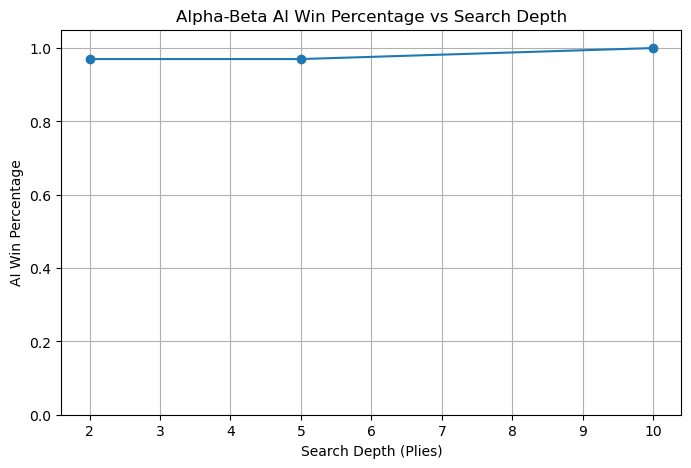

In [16]:
import matplotlib.pyplot as plt

depths = [2, 5, 10]
win_rates = []

for depth in depths:
    results = simulate_alpha_beta_vs_random(num_games=100, depth=depth, ai_player=1)
    win_rates.append(results["ai_wins"] / 100)

plt.figure(figsize=(8,5))
plt.plot(depths, win_rates, marker='o')
plt.xlabel("Search Depth (Plies)")
plt.ylabel("AI Win Percentage")
plt.title("Alpha-Beta AI Win Percentage vs Search Depth")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()